# **Laboratorio Aprendizaje Automático**
## Sesión Práctica 4 - Métricas de evaluación
2026-1

In [ ]:
#Importar datos
import kagglehub

path = kagglehub.dataset_download("uciml/red-wine-quality-cortez-et-al-2009")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'red-wine-quality-cortez-et-al-2009' dataset.
Path to dataset files: /kaggle/input/red-wine-quality-cortez-et-al-2009


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_validate, \
cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, \
precision_score, recall_score, f1_score, classification_report, accuracy_score, \
roc_curve, auc, RocCurveDisplay, make_scorer

from scipy.stats import binomtest
from scipy.stats import ttest_rel

In [ ]:
csv_path = path +'/winequality-red.csv'

wine_df = pd.read_csv(csv_path, sep=',', on_bad_lines='skip')
display(wine_df.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


# **MATRIZ DE CONFUSIÓN, MÉTRICAS Y ROC**
<center>

<div>
<center>
<img src="https://drive.google.com/uc?export=view&id=1nRDXu59OeMoJ_Ec9P3yzn2wZaS2-O5UR" width="400"/>
</center>
</div>

</center>

1. Exactitud / Accuracy (ACC)
  - Denota la cantidad de aciertos totales de la predicción del modelo, por lo que es una métrica general.

$$ACC = \dfrac{TP + TN}{n}$$

2. Error
$$Error = 1 - ACC = \dfrac{FN + FP}{n}$$

3. *true positive rate* (TPR) y *false positive rate* (FPR)
  - Proporciones de falso positivos y verdaderos positivos. Se toma en base una clase (positiva o negativa) y su cantidad de predicciones.

  $$
  TPR = \dfrac{TP}{P} = \dfrac{TP}{TP + FN} \\
  FPR = \dfrac{FP}{N} = \dfrac{FP}{FP + TN}
  $$

  Es fácil ver que $P$, la cantidad de observaciones positivas, está compuesta por los verdaderos positivos y los **falsos negativos** (es decir, aquellos que realmente son positivos).

  En forma similar $N$ es la suma de los verdaderos negativos y falsos positivos (aquellos que realmente son negativos).


4. Sensibilidad / Sensitivity o Recall (REC)
  - Muchos nombres pero es equivalente a la métrica TPR (énfasis en FN). Explica cuántos elementos de la clase positiva son realmente clasificados como positivos por el modelo.

5. Precision (PRE)
  - Cuantifica la cantidad de instancias realmente positivas entre todas las que el modelo clasificó como positivas (énfasis en FP).
  $$
  PRE = \dfrac{TP}{TP+FP}
  $$

6. Puntaje F1 / F1-*score*
  - Media armónica entre la precisión y la sensibilidad. Es básicamente una forma de resumir el desempeño del modelo de forma general, según las tasas ya vistas.
  $$
  F_1-\text{score} = 2\dfrac{PRE \cdot REC}{PRE+REC}
  $$

## Preparación del dataset

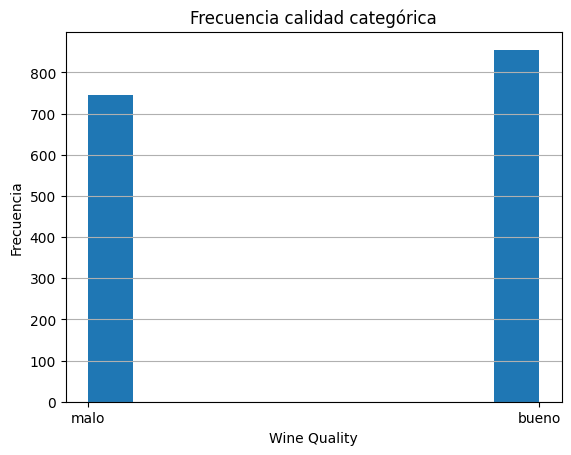

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   fixed acidity         1599 non-null   float64 
 1   volatile acidity      1599 non-null   float64 
 2   citric acid           1599 non-null   float64 
 3   residual sugar        1599 non-null   float64 
 4   chlorides             1599 non-null   float64 
 5   free sulfur dioxide   1599 non-null   float64 
 6   total sulfur dioxide  1599 non-null   float64 
 7   density               1599 non-null   float64 
 8   pH                    1599 non-null   float64 
 9   sulphates             1599 non-null   float64 
 10  alcohol               1599 non-null   float64 
 11  quality_categorical   1599 non-null   category
dtypes: category(1), float64(11)
memory usage: 139.2 KB


None

In [ ]:
# Adaptamos el dataset a un problema de clasificación binaria.
# Para esto utilizamos el método cut de pandas, para crear la
# variable quality_categorical, agrupada en bins en base a la
# variable quality (0, 5] y (5, 10]
#
# Decidimos que "Bueno" es la clase positiva.

wine_df['quality_categorical'] = pd.cut(
  wine_df['quality'],
  bins = [0, 5, 10],
  labels = ['malo', 'bueno'],
)

wine_df.drop('quality', axis=1, inplace=True)

wine_df['quality_categorical'].hist()
plt.title('Frecuencia calidad categórica')
plt.xlabel('Wine Quality')
plt.ylabel('Frecuencia')
plt.grid(axis='x')
plt.show()

# Dropeamos la variable quality, y ahora contamos con
# quality_categorical
display(wine_df.info())

## División de subconjuntos train y test

In [ ]:
# Igual que en la sesión práctica 3

def divide_partition_set(df, target_column):
  y = df[target_column].copy()
  X = df.drop(target_column, axis=1)
  return X, y

train_ds, test_ds = train_test_split(
    wine_df,
    stratify = wine_df['quality_categorical'],
    test_size = 0.3,
    random_state=42)

train_x, train_y = divide_partition_set(train_ds, 'quality_categorical')
test_x, test_y = divide_partition_set(test_ds, 'quality_categorical')

display(train_x.info())
display(test_x.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1119 entries, 557 to 255
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1119 non-null   float64
 1   volatile acidity      1119 non-null   float64
 2   citric acid           1119 non-null   float64
 3   residual sugar        1119 non-null   float64
 4   chlorides             1119 non-null   float64
 5   free sulfur dioxide   1119 non-null   float64
 6   total sulfur dioxide  1119 non-null   float64
 7   density               1119 non-null   float64
 8   pH                    1119 non-null   float64
 9   sulphates             1119 non-null   float64
 10  alcohol               1119 non-null   float64
dtypes: float64(11)
memory usage: 104.9 KB


None

<class 'pandas.core.frame.DataFrame'>
Index: 480 entries, 65 to 1560
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         480 non-null    float64
 1   volatile acidity      480 non-null    float64
 2   citric acid           480 non-null    float64
 3   residual sugar        480 non-null    float64
 4   chlorides             480 non-null    float64
 5   free sulfur dioxide   480 non-null    float64
 6   total sulfur dioxide  480 non-null    float64
 7   density               480 non-null    float64
 8   pH                    480 non-null    float64
 9   sulphates             480 non-null    float64
 10  alcohol               480 non-null    float64
dtypes: float64(11)
memory usage: 45.0 KB


None

## Definición del modelo y Entrenamiento

In [ ]:
# Clasificador binario (Random forest)
bin_clf = RandomForestClassifier(random_state=42)
bin_clf.fit(train_x, train_y)

# Predicciones del modelo
y_pred = bin_clf.predict(test_x)
y_prob = bin_clf.predict_proba(test_x)[:, 1]    # Probabilidades para clase positiva.
                                                # Útiles para la curva ROC

## Matriz de confusión

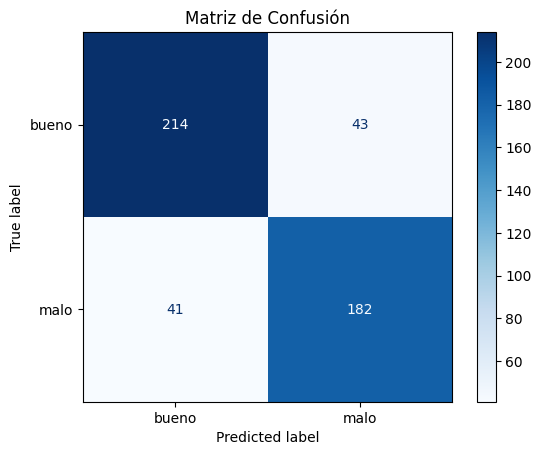

In [ ]:
#display(bin_clf.classes_)

cm = confusion_matrix(test_y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=bin_clf.classes_)
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión")
plt.show()

## Métricas

In [ ]:
# Definir diccionario scorer para métricas de rendimiento
scoring = {
    "accuracy": make_scorer(accuracy_score),
    "precision": make_scorer(precision_score, pos_label="bueno"),
    "recall": make_scorer(recall_score, pos_label="bueno"),
    "f1": make_scorer(f1_score, pos_label="bueno"),
}

# 5-folds
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Ejecutar validación cruzada
results = cross_validate(
    bin_clf,
    train_x,
    train_y,
    cv=kfold,
    scoring=scoring,
    return_train_score=False
)

for metric in scoring.keys():
    mean_val = results[f"test_{metric}"].mean()
    std_val = results[f"test_{metric}"].std()
    print(f"{metric.capitalize()}: mean {mean_val:.3f} (sigma = {std_val:.3f})")

Accuracy: mean 0.786 (sigma = 0.023)
Precision: mean 0.785 (sigma = 0.019)
Recall: mean 0.826 (sigma = 0.035)
F1: mean 0.805 (sigma = 0.022)


## Curva ROC

La curva ROC (*Receiver-Operating Characteristic curve*) corresponde a una representación gráfica del desempeño del modelo **frente a distintos umbrales de "rigurosidad" para las predicciones de la clase positiva**.

Un ejemplo bien útil que se encuentra en un [*crash course* de Google](https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc): "In more concrete terms, a spam classifier with AUC of 1.0 always assigns a random spam email a higher probability of being spam than a random legitimate email. The actual classification of each email depends on the threshold that you choose".

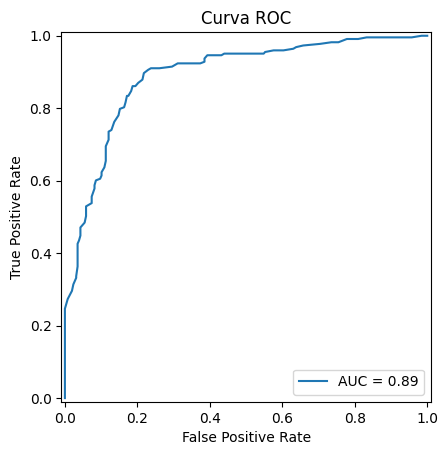

0.89046


In [ ]:
# Obtención de curva ROC
fpr, tpr, thresholds = roc_curve(test_y, y_prob, pos_label=bin_clf.classes_[1])
roc_auc = auc(fpr, tpr)

RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc).plot()
plt.title("Curva ROC")
plt.show()

print(f"{roc_auc:.5f}")

## Evaluación de Clasificador mediante Test de Hipótesis

In [ ]:
# Test Binomial

acc = accuracy_score(test_y, y_pred)
n = len(test_y)
correct = np.sum(y_pred == test_y)

# Hipótesis nula: la exactitud del Clasificador = 75%
binom_test_results = binomtest(correct, n, p=0.75, alternative='greater')

print(f"Accuracy = {acc:.3f}, p-value = {binom_test_results.pvalue}")
if binom_test_results.pvalue < 0.05:
    print("Hipótesis nula rechazada")
else:
    print("Hipótesis nula no rechazada")

Accuracy = 0.825, p-value = 5.264641751668059e-05
Hipótesis nula rechazada


## Comparación de Modelos mediante Test de Hipótesis

In [ ]:
# Definición de segundo modelo
second_bin_clf = LogisticRegression(max_iter=1000)
second_bin_clf.fit(train_x, train_y)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores_rf = cross_val_score(bin_clf, test_x, test_y, cv=kf, scoring="accuracy")
scores_lr = cross_val_score(second_bin_clf, test_x, test_y, cv=kf, scoring="accuracy")

t_stat, p_value = ttest_rel(scores_rf, scores_lr)

print("Métricas para Clasificador Binario Random Forest:", scores_rf)
print("Métricas para Clasificador Binario Regresión Logística:", scores_lr)
print(f"Paired t-test: t = {t_stat:.3f}, p = {p_value:.4f}")

# Hipótesis nula: Clasificadores tienen la misma exactitud (promedio)
if p_value < 0.05:
    print("Hipótesis nula rechazada")
else:
    print("Hipótesis nula no rechazada")

Métricas para Clasificador Binario Random Forest: [0.84375    0.73958333 0.73958333 0.82291667 0.77083333]
Métricas para Clasificador Binario Regresión Logística: [0.80208333 0.75       0.70833333 0.8125     0.77083333]
Paired t-test: t = 1.510, p = 0.2056
Hipótesis nula no rechazada
